In [1]:
# Импорты сюдаа
import numpy as np
import matplotlib.pyplot as plt

In [16]:
class SeismicGenerator:
    """
    Генератор синтетических сейсмических трасс на основе свёрточной модели.
    """
    
    def __init__(self, wavelet_type='ricker', wavelet_freq=30, dt=0.002):
        """
        Инициализация генератора.

        Параметры:
        ----------
        wavelet_type : str
            Тип импульса источника ('ricker')
        wavelet_freq : float
            Доминантная частота импульса (Гц)
        dt : float
            Интервал дискретизации по времени (секунды)
        """
        self.wavelet_type = wavelet_type
        self.wavelet_freq = wavelet_freq
        self.dt = dt
        
        # Для хранения сгенерированного импульса
        self.wavelet = None
        self.wavelet_time = None
    
    def _create_ricker_wavelet(self, length=0.128):
        """
        Создаёт вейвлет Рикера заданной длительности.

        Параметры:
        ----------
        length : float
            Длительность импульса в секундах (должна быть достаточно большой,
            чтобы импульс затух до нуля)
        """
        # Временная сетка для импульса
        t = np.arange(-length/2, length/2, self.dt) #создаёт массив чисел от -0.064 до 0.064 с шагом self.dt (0.002 сек)
        f = self.wavelet_freq
        
        # Формула вейвлета Рикера
        tau = np.pi * f * t
        wavelet = (1 - 2 * tau**2) * np.exp(-tau**2)
        
        # Нормализация (максимальная амплитуда = 1)
        wavelet = wavelet / np.max(np.abs(wavelet))
        
        return t, wavelet
    
    def _get_wavelet(self):
        """
        Возвращает импульс источника (создаёт, если ещё не создан).
        """
        if self.wavelet is None:
            if self.wavelet_type == 'ricker':
                t, w = self._create_ricker_wavelet()
                self.wavelet_time = t
                self.wavelet = w
            else:
                raise ValueError(f"Неподдерживаемый тип вейвлета: {self.wavelet_type}")
        return self.wavelet
    
    def generate_trace(self, reflectivity_series, noise_level=0.0):
        """
        Генерирует сейсмическую трассу по коэффициентам отражения.

        Параметры:
        ----------
        reflectivity_series : np.ndarray
            Массив коэффициентов отражения (по времени) — например,
            [0, 0, 0.3, 0, -0.1, 0, ...]
            Длина массива определяет длительность трассы в отсчётах.
        noise_level : float
            Уровень аддитивного белого шума (0 = нет шума, 0.1 = 10% от RMS сигнала)

        Возвращает:
        ----------
        trace : np.ndarray
            Синтетическая трасса (той же длины, что reflectivity_series)
        """
        # 1. Получаем импульс источника
        wavelet = self._get_wavelet()
        
        # 2. Свёртка коэффициентов отражения с импульсом
        #    'full' -> полная свёртка, потом обрезаем до длины reflectivity_series
        trace_full = np.convolve(reflectivity_series, wavelet, mode='full')
        
        # 3. Обрезаем до нужной длины (чтобы сохранить временную ось как у reflectivity_series)
        trace = trace_full[:len(reflectivity_series)]
        
        # 4. Добавляем шум (если нужно)
        if noise_level > 0:
            # Оцениваем RMS сигнала
            rms_signal = np.sqrt(np.mean(trace**2))
            # Генерируем шум
            noise = np.random.randn(len(trace)) * noise_level * rms_signal
            trace = trace + noise
        
        return trace
    
    def plot_wavelet(self):
        """Визуализирует импульс источника."""
        wavelet = self._get_wavelet()
        plt.figure(figsize=(5, 2))
        plt.plot(self.wavelet_time, wavelet)
        plt.title(f"Импульс источника по умолчанию ({self.wavelet_type}, freq={self.wavelet_freq} Гц)")
        plt.xlabel("Время (с)")
        plt.ylabel("Амплитуда")
        plt.grid(True)
        plt.show()

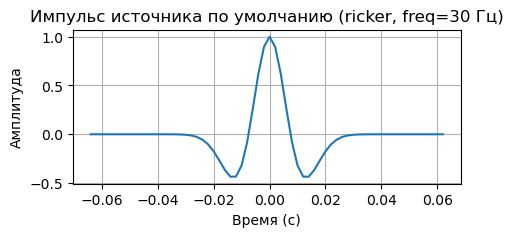

In [17]:
# Генератор с росписью параметров
gen = SeismicGenerator() # wavelet_type='ricker', wavelet_freq=30, dt=0.002

# Посмотрим на импульс
gen.plot_wavelet()

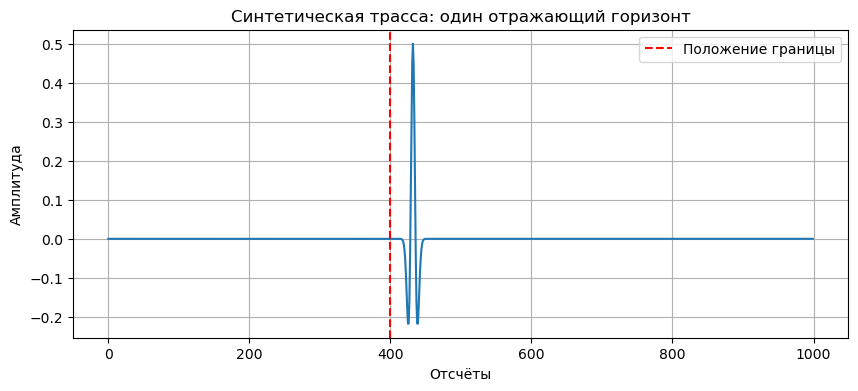

In [4]:
# Создаём массив коэффициентов отражения (все нули, кроме одного)
num_samples = 1000
reflectivity = np.zeros(num_samples)

# Горизонт на 400-м отсчёте (время = 400 * 0.002 = 0.8 с)
sample_index = 400
reflectivity[sample_index] = 0.5   # коэффициент отражения 0.5

# Генерируем трассу
trace = gen.generate_trace(reflectivity, noise_level=0.0)

# Визуализация
plt.figure(figsize=(10, 4))
plt.plot(trace)
plt.axvline(x=sample_index, color='red', linestyle='--', label='Положение границы')
plt.title("Синтетическая трасса: один отражающий горизонт")
plt.xlabel("Отсчёты")
plt.ylabel("Амплитуда")
plt.legend()
plt.grid(True)
plt.show()

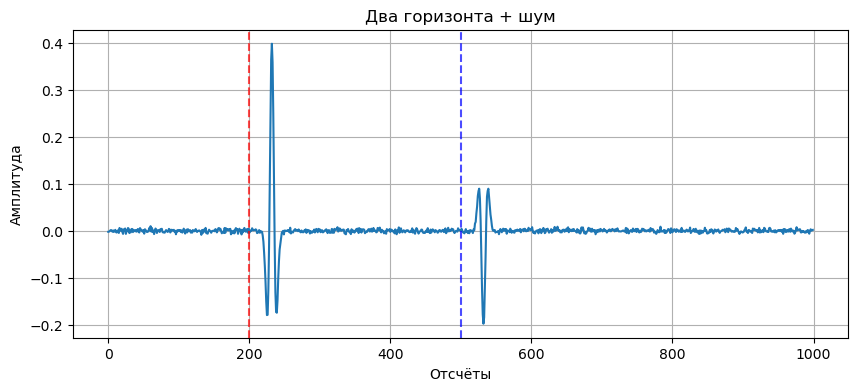

In [5]:
reflectivity2 = np.zeros(1000)
reflectivity2[200] = 0.4   # первый горизонт
reflectivity2[500] = -0.2  # второй горизонт (отрицательный контраст)

trace2 = gen.generate_trace(reflectivity2, noise_level=0.1)

plt.figure(figsize=(10, 4))
plt.plot(trace2)
plt.axvline(x=200, color='red', linestyle='--', alpha=0.7)
plt.axvline(x=500, color='blue', linestyle='--', alpha=0.7)
plt.title("Два горизонта + шум")
plt.xlabel("Отсчёты")
plt.ylabel("Амплитуда")
plt.grid(True)
plt.show()

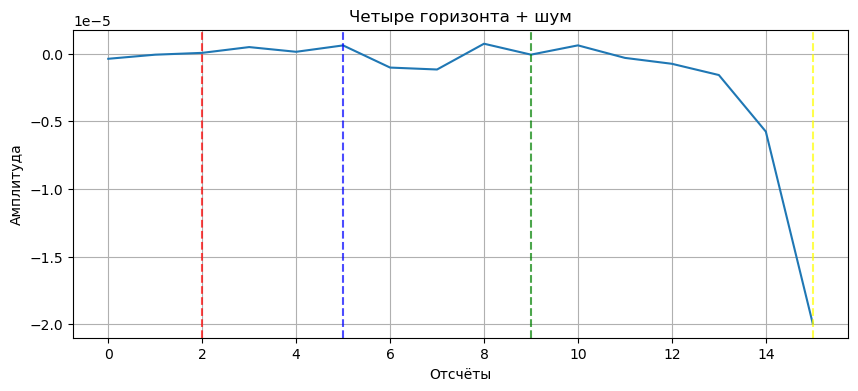

In [13]:
reflectivity3 = np.array([0.0, 0.0, 0.3, 0.0, 0.0, -0.2, 0.0, 0.0, 0.0, 0.6, 0.0, 0.0, 0.0, 0.0, 0.0, -0.2])
# удобнее отдельные указывать, но можно и весь массив прописать при желании
#reflectivity3[200] = 0.4   # первый горизонт
#reflectivity3[500] = -0.2  # второй горизонт (отрицательный контраст)

trace3 = gen.generate_trace(reflectivity3, noise_level=0.1)

plt.figure(figsize=(10, 4))
plt.plot(trace3)
plt.axvline(x=2, color='red', linestyle='--', alpha=0.7)
plt.axvline(x=5, color='blue', linestyle='--', alpha=0.7)
plt.axvline(x=9, color='green', linestyle='--', alpha=0.7)
plt.axvline(x=15, color='yellow', linestyle='--', alpha=0.7)
plt.title("Четыре горизонта + шум")
plt.xlabel("Отсчёты")
plt.ylabel("Амплитуда")
plt.grid(True)
plt.show()

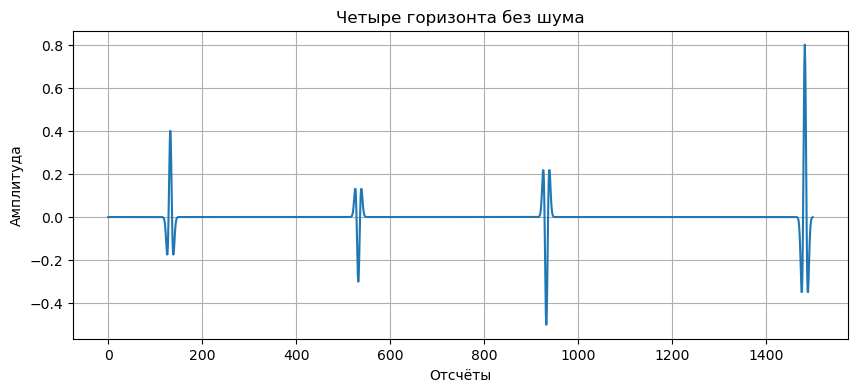

In [15]:
reflectivity4 = np.zeros(1500)
# удобнее отдельные указывать, но можно и весь массив прописать при особом желании
reflectivity4[100] = 0.4   # первый горизонт
reflectivity4[500] = -0.3  # второй горизонт
reflectivity4[900] = -0.5  # третий горизонт
reflectivity4[1450] = 0.8  # четвёртый горизонт

trace4 = gen.generate_trace(reflectivity4, noise_level=0.0)

plt.figure(figsize=(10, 4))
plt.plot(trace4)
plt.title("Четыре горизонта без шума")
plt.xlabel("Отсчёты")
plt.ylabel("Амплитуда")
plt.grid(True)
plt.show()